In [100]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Loading up the Ames Housing dataset

In [101]:
from sklearn.datasets import fetch_openml
housing = fetch_openml(name="house_prices", as_frame=True)
print(housing)

{'data':         Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0        1          60       RL         65.0     8450   Pave   NaN      Reg   
1        2          20       RL         80.0     9600   Pave   NaN      Reg   
2        3          60       RL         68.0    11250   Pave   NaN      IR1   
3        4          70       RL         60.0     9550   Pave   NaN      IR1   
4        5          60       RL         84.0    14260   Pave   NaN      IR1   
...    ...         ...      ...          ...      ...    ...   ...      ...   
1455  1456          60       RL         62.0     7917   Pave   NaN      Reg   
1456  1457          20       RL         85.0    13175   Pave   NaN      Reg   
1457  1458          70       RL         66.0     9042   Pave   NaN      Reg   
1458  1459          20       RL         68.0     9717   Pave   NaN      Reg   
1459  1460          20       RL         75.0     9937   Pave   NaN      Reg   

     LandContour Utilities  ... ScreenPorc

In [102]:
housing.keys()

dict_keys(['data', 'target', 'frame', 'categories', 'feature_names', 'target_names', 'DESCR', 'details', 'url'])

In [103]:
## Lets Check the description to begin with
print(housing.DESCR)

Ask a home buyer to describe their dream house, and they probably won't begin with the height of the basement ceiling or the proximity to an east-west railroad. But this playground competition's dataset proves that much more influences price negotiations than the number of bedrooms or a white-picket fence.

With 79 explanatory variables describing (almost) every aspect of residential homes in Ames, Iowa, this competition challenges you to predict the final price of each home.

MSSubClass: Identifies the type of dwelling involved in the sale.	

        20	1-STORY 1946 & NEWER ALL STYLES
        30	1-STORY 1945 & OLDER
        40	1-STORY W/FINISHED ATTIC ALL AGES
        45	1-1/2 STORY - UNFINISHED ALL AGES
        50	1-1/2 STORY FINISHED ALL AGES
        60	2-STORY 1946 & NEWER
        70	2-STORY 1945 & OLDER
        75	2-1/2 STORY ALL AGES
        80	SPLIT OR MULTI-LEVEL
        85	SPLIT FOYER
        90	DUPLEX - ALL STYLES AND AGES
       120	1-STORY PUD (Planned Unit Development) - 1

In [104]:
print(housing.data)

        Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0        1          60       RL         65.0     8450   Pave   NaN      Reg   
1        2          20       RL         80.0     9600   Pave   NaN      Reg   
2        3          60       RL         68.0    11250   Pave   NaN      IR1   
3        4          70       RL         60.0     9550   Pave   NaN      IR1   
4        5          60       RL         84.0    14260   Pave   NaN      IR1   
...    ...         ...      ...          ...      ...    ...   ...      ...   
1455  1456          60       RL         62.0     7917   Pave   NaN      Reg   
1456  1457          20       RL         85.0    13175   Pave   NaN      Reg   
1457  1458          70       RL         66.0     9042   Pave   NaN      Reg   
1458  1459          20       RL         68.0     9717   Pave   NaN      Reg   
1459  1460          20       RL         75.0     9937   Pave   NaN      Reg   

     LandContour Utilities  ... ScreenPorch PoolAre

In [105]:
print(housing.feature_names)

['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond', 'PavedDrive', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'PoolQC'

In [106]:
dataset = pd.DataFrame(housing.data, columns=housing.feature_names)
dataset.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal


In [107]:
dataset['Price'] = housing.target
dataset.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,Price
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [108]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [109]:
## Check for missing values
dataset.isnull().sum().sort_values(ascending=False)

PoolQC           1453
MiscFeature      1406
Alley            1369
Fence            1179
FireplaceQu       690
                 ... 
MoSold              0
YrSold              0
SaleType            0
SaleCondition       0
Price               0
Length: 81, dtype: int64

In [110]:
## figure out the type of data in columns that have missing values
dataset.dtypes[dataset.isnull().sum() > 0]

LotFrontage     float64
Alley               str
MasVnrType          str
MasVnrArea      float64
BsmtQual            str
BsmtCond            str
BsmtExposure        str
BsmtFinType1        str
BsmtFinType2        str
Electrical          str
FireplaceQu         str
GarageType          str
GarageYrBlt     float64
GarageFinish        str
GarageQual          str
GarageCond          str
PoolQC              str
Fence               str
MiscFeature         str
dtype: object

<Axes: >

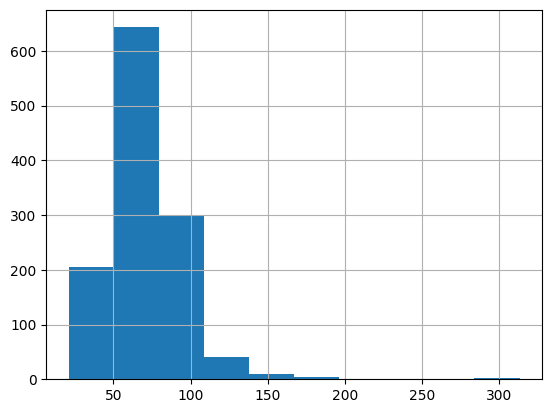

In [111]:
## We have 2 columns with missing values, one is numerical and the other is categorical. We will handle them separately.
## Lets handle the numerical column first
dataset['LotFrontage'].describe()
dataset['LotFrontage'].hist()


<Axes: >

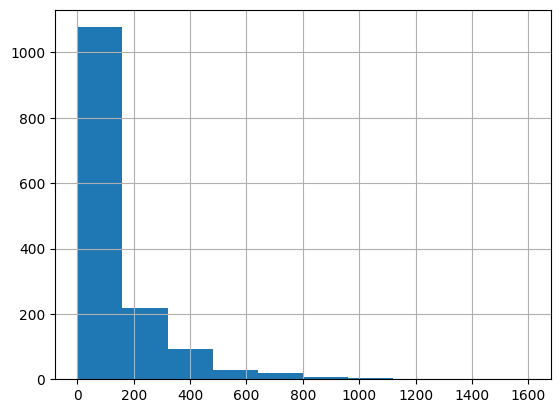

In [112]:
dataset['MasVnrArea'].describe()
dataset['MasVnrArea'].hist()

In [113]:
dataset.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

<Axes: xlabel='MSZoning', ylabel='Price'>

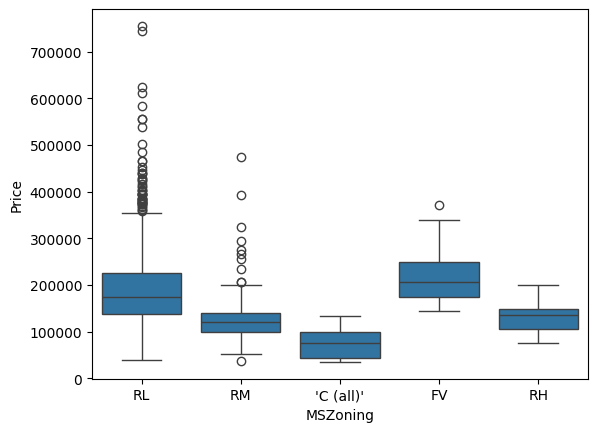

In [114]:
sns.boxplot(x='MSZoning', y='Price', data=dataset)

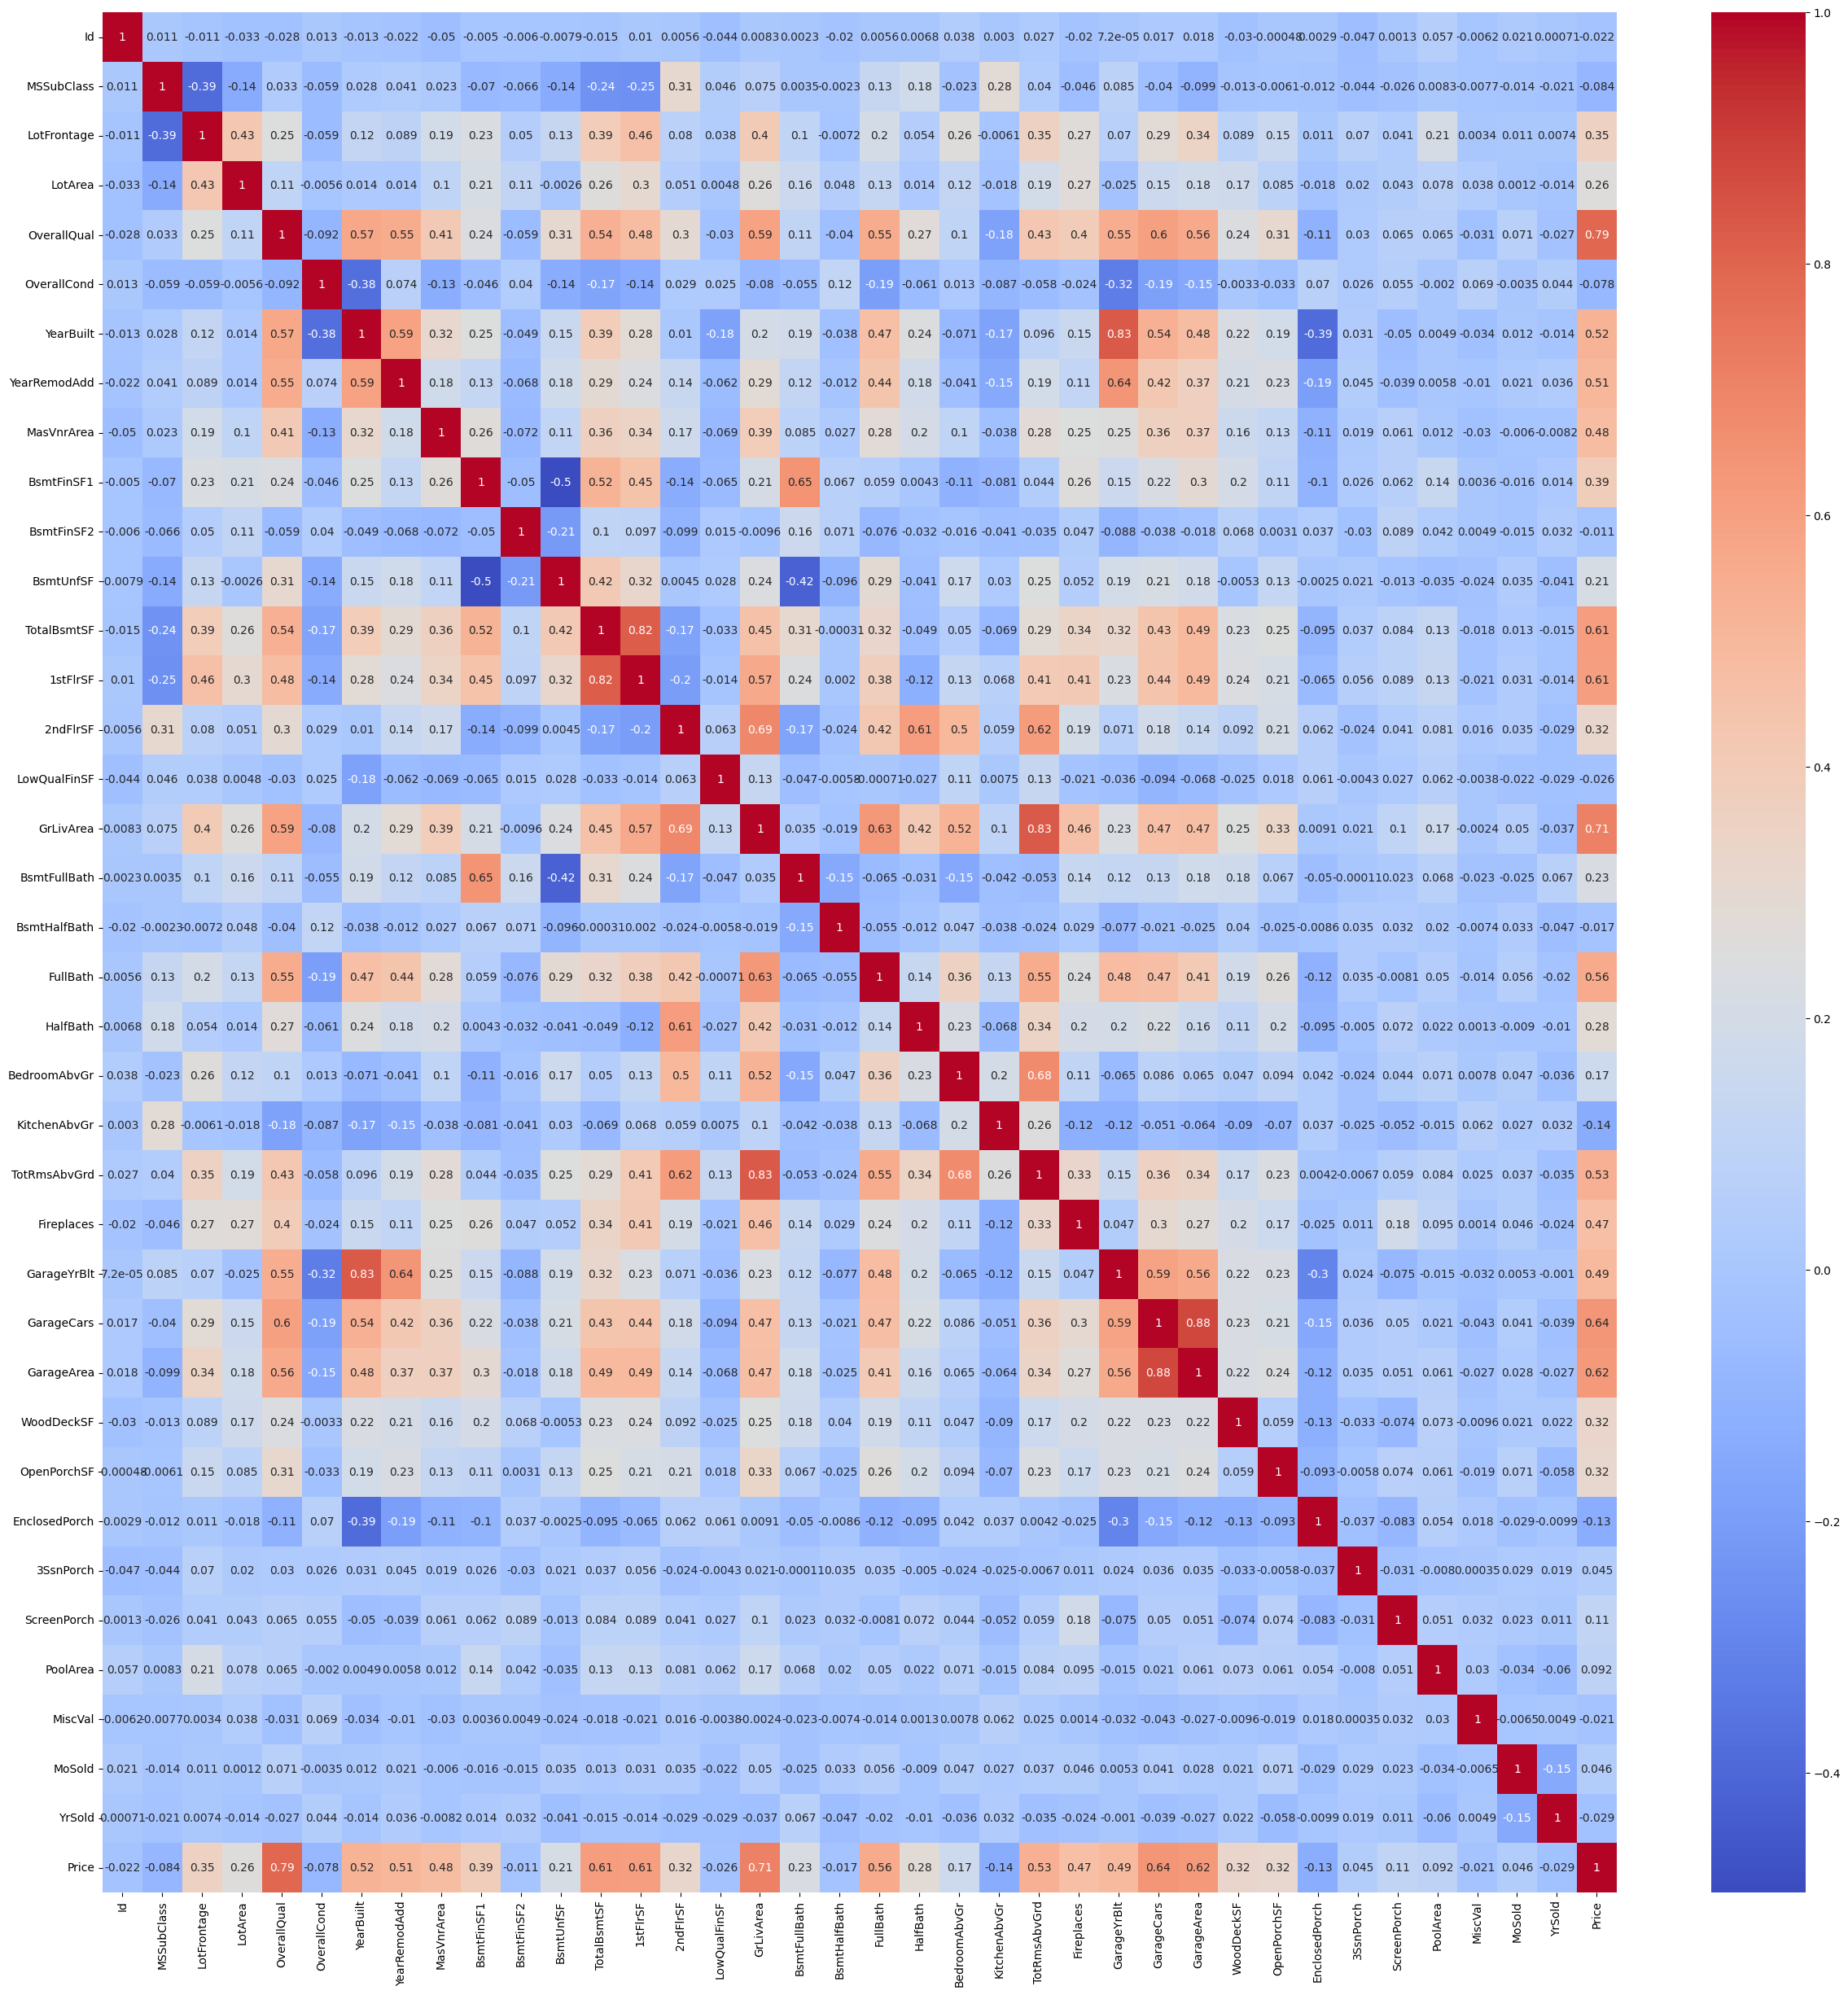

In [115]:
# This tells Pandas: "Only look at the numbers, ignore the text for now."
correlation_matrix = dataset.corr(numeric_only=True)

plt.figure(figsize=(30, 30))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.show()

In [116]:
cols_to_drop = [
    'Id', 'MSSubClass', 'OverallCond', 'BsmtFinSF2', 'LowQualFinSF', 
    'BsmtHalfBath', '3SsnPorch', 'ScreenPorch', 'PoolArea', 
    'MiscVal', 'MoSold', 'YrSold', 'EnclosedPorch', 'KitchenAbvGr',
]

dataset.drop(columns=cols_to_drop, inplace=True, errors='ignore')
dataset.head()

,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,...,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,PoolQC,Fence,MiscFeature,SaleType,SaleCondition,Price
0,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,...,TA,Y,0,61,NaN,NaN,NaN,WD,Normal,208500
1,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,...,TA,Y,298,0,NaN,NaN,NaN,WD,Normal,181500
2,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,...,TA,Y,0,42,NaN,NaN,NaN,WD,Normal,223500
3,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,...,TA,Y,0,35,NaN,NaN,NaN,WD,Abnorml,140000
4,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,...,TA,Y,192,84,NaN,NaN,NaN,WD,Normal,250000


In [117]:
dataset.columns

Index(['MSZoning', 'LotFrontage', 'LotArea', 'Street', 'Alley', 'LotShape',
       'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood',
       'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'OverallQual',
       'YearBuilt', 'YearRemodAdd', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'MasVnrArea', 'ExterQual', 'ExterCond',
       'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1',
       'BsmtFinSF1', 'BsmtFinType2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'GrLivArea', 'BsmtFullBath', 'FullBath', 'HalfBath', 'BedroomAbvGr',
       'KitchenQual', 'TotRmsAbvGrd', 'Functional', 'Fireplaces',
       'FireplaceQu', 'GarageType', 'GarageYrBlt', 'GarageFinish',
       'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond', 'PavedDrive',
       'WoodDeckSF', 'OpenPorchSF', 'PoolQC', 'Fence', 'MiscFeature',
       'SaleType', 'SaleCondition', 'P

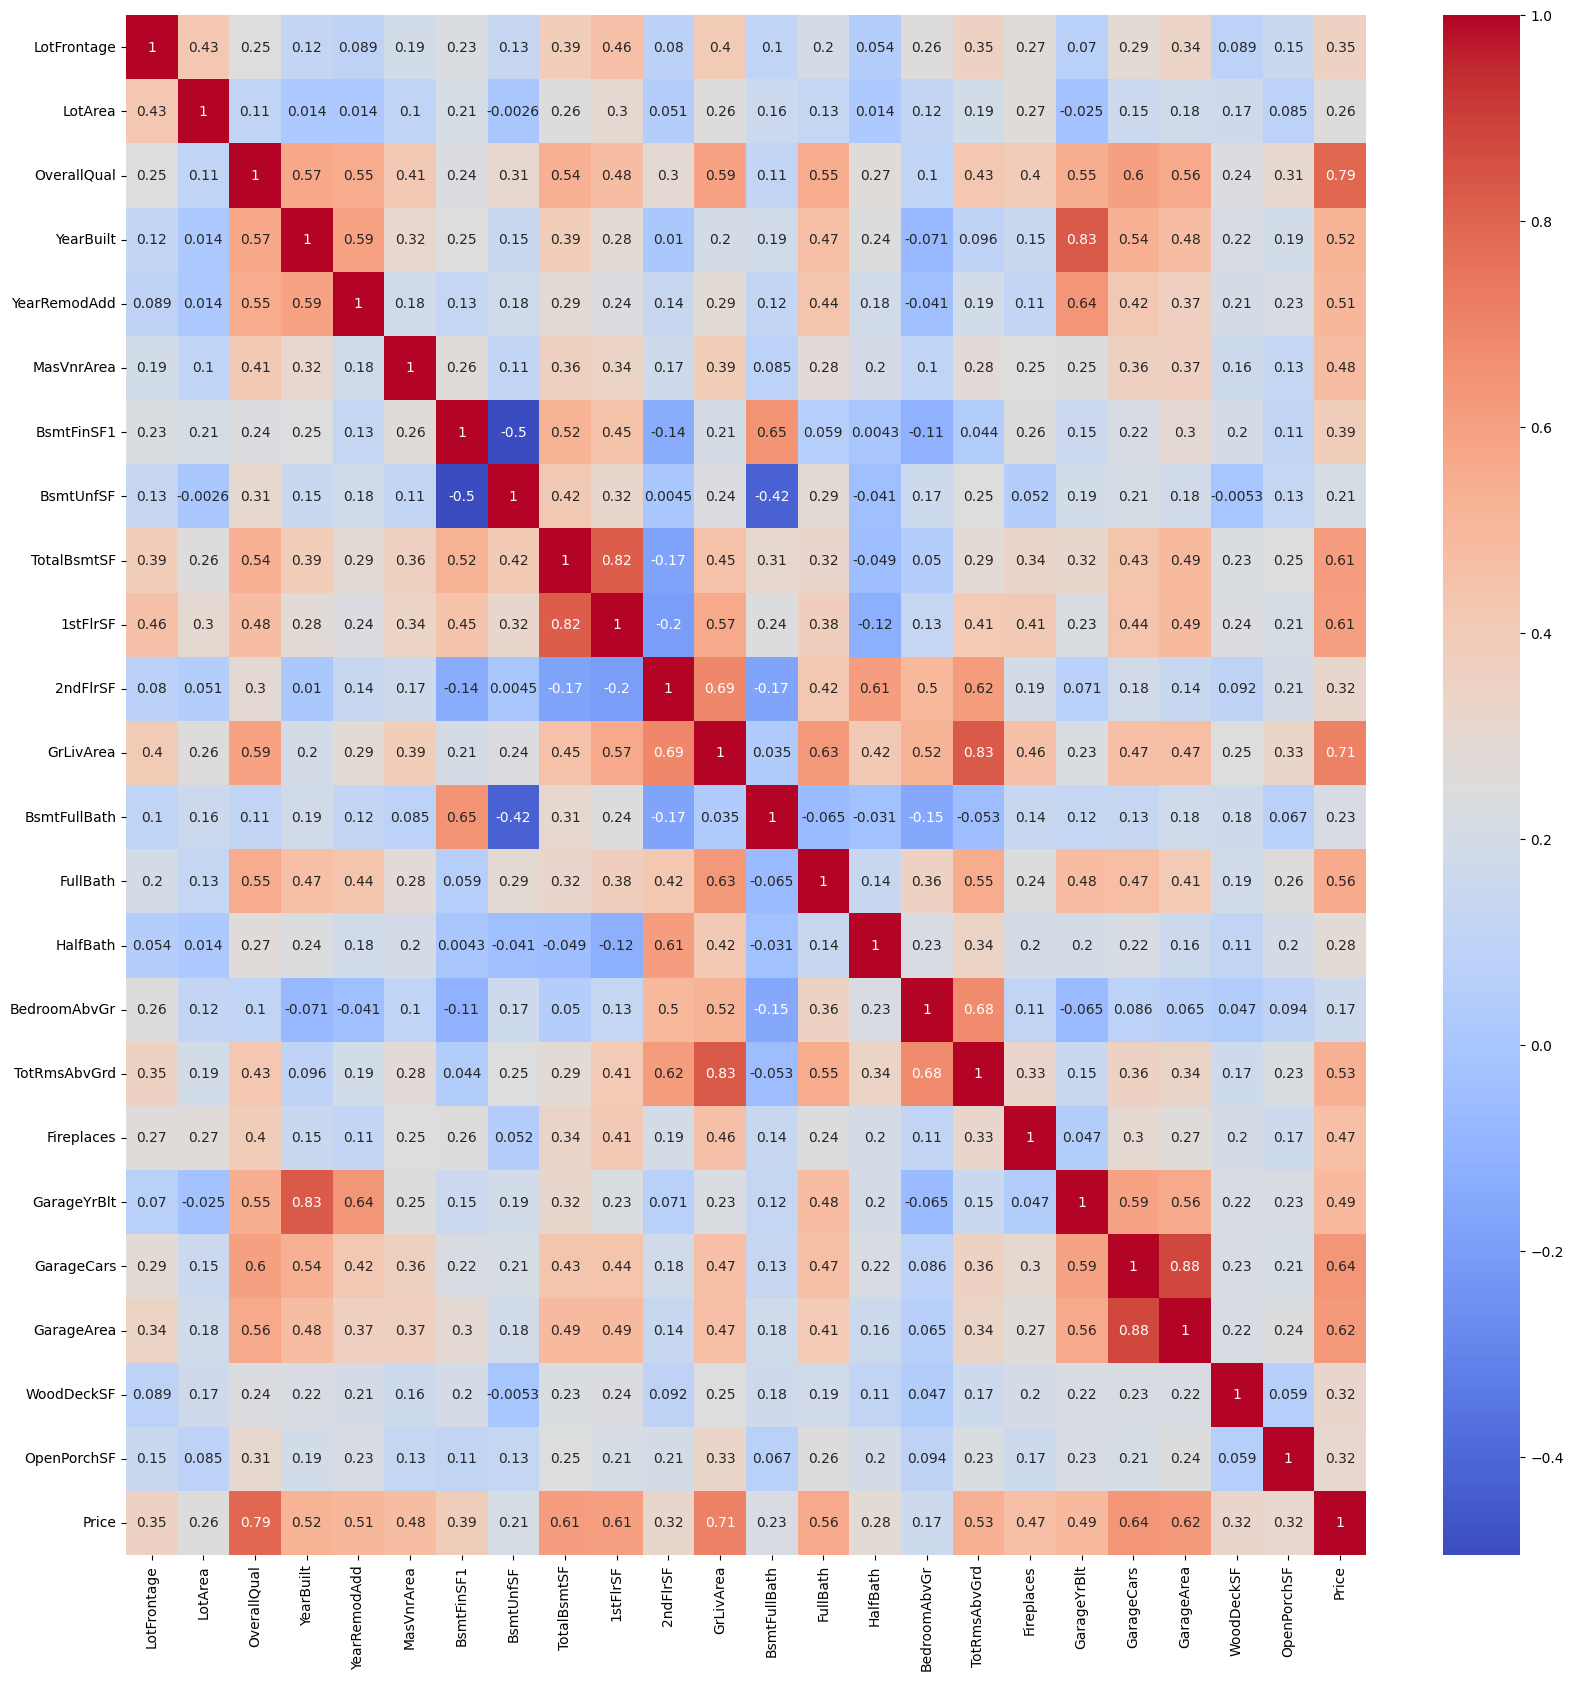

In [118]:
correlation_matrix = dataset.corr(numeric_only=True)

plt.figure(figsize=(20, 20))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.show()

In [119]:
cols_to_drop = [
    'MiscFeature', 'Fence', 'PoolQC', 'Alley'
]

dataset.drop(columns=cols_to_drop, inplace=True, errors='ignore')
dataset.head()

,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,...,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,SaleType,SaleCondition,Price
0,RL,65.0,8450,Pave,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,...,2,548,TA,TA,Y,0,61,WD,Normal,208500
1,RL,80.0,9600,Pave,Reg,Lvl,AllPub,FR2,Gtl,Veenker,...,2,460,TA,TA,Y,298,0,WD,Normal,181500
2,RL,68.0,11250,Pave,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,...,2,608,TA,TA,Y,0,42,WD,Normal,223500
3,RL,60.0,9550,Pave,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,...,3,642,TA,TA,Y,0,35,WD,Abnorml,140000
4,RL,84.0,14260,Pave,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,...,3,836,TA,TA,Y,192,84,WD,Normal,250000


<Axes: xlabel='FireplaceQu', ylabel='Price'>

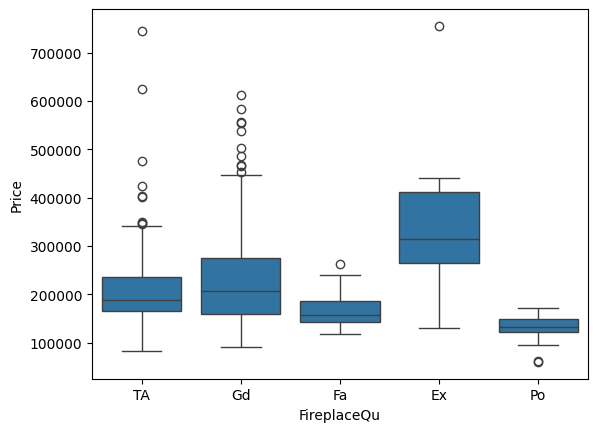

In [120]:
sns.boxplot(x='FireplaceQu', y='Price', data=dataset)

In [121]:
dataset['FireplaceQu'] = dataset['FireplaceQu'].fillna('None')
dataset["LotFrontage"] = dataset.groupby("Neighborhood")["LotFrontage"].transform(
    lambda x: x.fillna(x.median())
)

In [122]:
dataset.head()

,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,...,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,SaleType,SaleCondition,Price
0,RL,65.0,8450,Pave,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,...,2,548,TA,TA,Y,0,61,WD,Normal,208500
1,RL,80.0,9600,Pave,Reg,Lvl,AllPub,FR2,Gtl,Veenker,...,2,460,TA,TA,Y,298,0,WD,Normal,181500
2,RL,68.0,11250,Pave,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,...,2,608,TA,TA,Y,0,42,WD,Normal,223500
3,RL,60.0,9550,Pave,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,...,3,642,TA,TA,Y,0,35,WD,Abnorml,140000
4,RL,84.0,14260,Pave,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,...,3,836,TA,TA,Y,192,84,WD,Normal,250000


<Axes: xlabel='GarageType', ylabel='Price'>

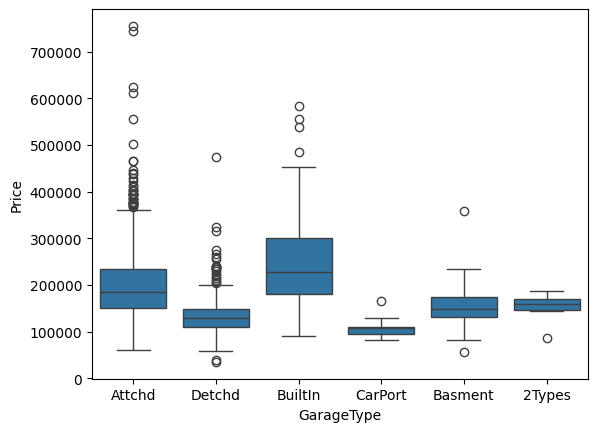

In [123]:
# We can see that the median price of houses with no fireplace is much lower than those with a fireplace. This makes sense, as a fireplace is often considered a desirable feature in a house. However, we also see that there are some outliers in the data, with some houses with no fireplace having very high prices. This could be due to other factors such as location, size, or other features of the house that are not captured in this analysis. Overall, it seems that having a fireplace is generally associated with higher house prices, but it is not the only factor that determines the price of a house.

sns.boxplot(x='GarageType', y='Price', data=dataset)

In [124]:
garage_cats = ['GarageType', 'GarageFinish', 'GarageQual', 'GarageCond']
dataset[garage_cats] = dataset[garage_cats].fillna('None')

# Instead of 0, use the house's build year
dataset['GarageYrBlt'] = dataset['GarageYrBlt'].fillna(dataset['YearBuilt'])

In [125]:
dataset.isnull().sum().sort_values(ascending=False)

BsmtExposure     38
BsmtFinType2     38
BsmtFinType1     37
BsmtCond         37
BsmtQual         37
                 ..
WoodDeckSF        0
OpenPorchSF       0
SaleType          0
SaleCondition     0
Price             0
Length: 63, dtype: int64

In [126]:
Bsmt_cats = ['BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2']
dataset[Bsmt_cats] = dataset[Bsmt_cats].fillna('None')

In [127]:
dataset.isnull().sum().sort_values(ascending=False)

MasVnrType       8
MasVnrArea       8
Electrical       1
Street           0
LotShape         0
                ..
WoodDeckSF       0
OpenPorchSF      0
SaleType         0
SaleCondition    0
Price            0
Length: 63, dtype: int64

In [128]:
dataset['MasVnrType'] = dataset['MasVnrType'].fillna('None')
dataset['MasVnrArea'] = dataset['MasVnrArea'].fillna(0)
# .mode() returns a Series, so we take the first element [0]
dataset['Electrical'] = dataset['Electrical'].fillna(dataset['Electrical'].mode()[0])

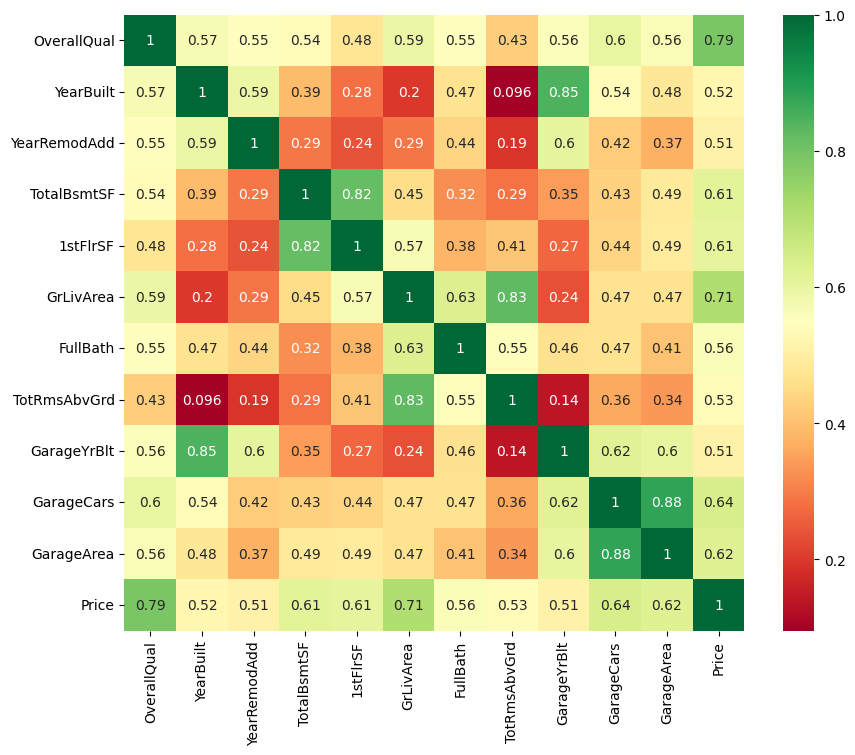

In [129]:
correlation = dataset.corr(numeric_only=True)
top_corr_features = correlation.index[abs(correlation["Price"]) > 0.5]
plt.figure(figsize=(10,8))
sns.heatmap(dataset[top_corr_features].corr(), annot=True, cmap="RdYlGn")
plt.show()

In [140]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from scipy.stats import skew

# 1. Start with your cleaned dataset (before splitting)
# Drop outliers first
dataset = dataset.drop(dataset[(dataset['GrLivArea']>4000) & (dataset['Price']<13)].index, errors='ignore')

# 1. Identify numeric columns
numeric_feats = dataset.select_dtypes(include=[np.number]).columns

# 2. Calculate skewness using Pandas (simple & fast)
skewness = dataset[numeric_feats].skew().sort_values(ascending=False)

# 3. Filter for highly skewed features
# A common threshold is 0.75
high_skew = skewness[abs(skewness) > 0.75].index

# 4. Apply Log Transformation
dataset[high_skew] = np.log1p(dataset[high_skew])

print(f"Number of skewed features transformed: {len(high_skew)}")

# 3. Encode & Split
X = pd.get_dummies(dataset.drop('Price', axis=1))
y = dataset['Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print(X.isnull().sum().max())

Number of skewed features transformed: 3
0


In [141]:
from sklearn.linear_model import LassoCV, RidgeCV
from xgboost import XGBRegressor
from sklearn.metrics import r2_score
import numpy as np

# 1. Initialize Experts
lasso = LassoCV(alphas=None, cv=10, max_iter=10000)
ridge = RidgeCV(alphas=[0.1, 1.0, 10.0, 100.0])
xgb = XGBRegressor(n_estimators=1000, learning_rate=0.05, max_depth=4, random_state=42)

# 2. Train
lasso.fit(X_train_scaled, y_train)
ridge.fit(X_train_scaled, y_train)
xgb.fit(X_train_scaled, y_train)

# 3. Predict & Blend (0.4/0.3/0.3 weights are a standard 'safe' starting point)
final_preds = (0.4 * lasso.predict(X_test_scaled)) + \
              (0.3 * ridge.predict(X_test_scaled)) + \
              (0.3 * xgb.predict(X_test_scaled))

print(f"Final Score: {r2_score(y_test, final_preds):.4f}")

c:\Users\chris\My Projects\Machine Learning projects\Boston Housing\myenv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:1682: FutureWarning: 'alphas=None' is deprecated and will be removed in 1.9, at which point the default value will be set to 100. Set 'alphas=100' to silence this warning.
  warnings.warn(


Final Score: 0.9158


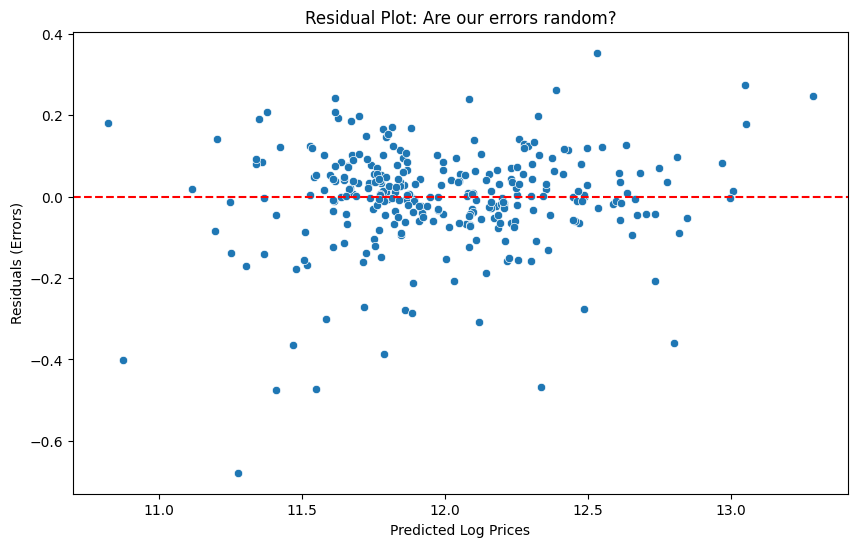

In [142]:
import matplotlib.pyplot as plt
import seaborn as sns

residuals = y_test - final_preds

plt.figure(figsize=(10, 6))
sns.scatterplot(x=final_preds, y=residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Log Prices')
plt.ylabel('Residuals (Errors)')
plt.title('Residual Plot: Are our errors random?')
plt.show()

In [144]:
# Create a DataFrame of the features and their coefficients
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lasso.coef_
})

# Get the absolute values to see the strongest impact (positive or negative)
coef_df['Abs_Coef'] = coef_df['Coefficient'].abs()
top_10_features = coef_df.sort_values(by='Abs_Coef', ascending=False).head(10)

print(top_10_features[['Feature', 'Coefficient']])

              Feature  Coefficient
11          GrLivArea     0.122475
2         OverallQual     0.079556
109  RoofMatl_ClyTile    -0.043119
4        YearRemodAdd     0.035176
1             LotArea     0.034384
3           YearBuilt     0.027207
9            1stFlrSF     0.026151
6          BsmtFinSF1     0.025171
224    Functional_Typ     0.023826
86    Condition2_PosN    -0.023598


In [146]:
import joblib
import os

# 1. Create the directory if it doesn't exist
model_path = '../models/'
if not os.path.exists(model_path):
    os.makedirs(model_path)

# 2. Save the Trio (The Ensemble)
joblib.dump(lasso, os.path.join(model_path, 'lasso_model.pkl'))
joblib.dump(ridge, os.path.join(model_path, 'ridge_model.pkl'))
joblib.dump(xgb, os.path.join(model_path, 'xgb_model.pkl'))

# 3. Save the Transformers & Metadata
joblib.dump(scaler, os.path.join(model_path, 'scaler.pkl'))
joblib.dump(list(X.columns), os.path.join(model_path, 'model_columns.pkl'))

['../models/model_columns.pkl']